<a href="https://colab.research.google.com/github/harsharouniyar/sweetcrete-ml-project/blob/main/GameTheory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()  # Click "Choose Files" and select Sweetcrete_Master_Final.csv

Saving Sweetcrete_Master_Final.csv to Sweetcrete_Master_Final (1).csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print(" SWEETCRETE: REINFORCEMENT LEARNING + GAME THEORY OPTIMIZATION")
print("="*80 + "\n")



 SWEETCRETE: REINFORCEMENT LEARNING + GAME THEORY OPTIMIZATION



In [5]:
print(" Loading data...")
df = pd.read_csv('Sweetcrete_Master_Final.csv')

# Clean data - remove NaN
df = df.dropna(subset=['Max_Load_lbf'])
df = df.dropna(subset=['Water_lbs', 'Cement_lbs', 'FineAgg_lbs', 'CoarseAgg_lbs', 'Age_days'])

print(f" Dataset: {len(df)} samples, {len(df.columns)} features")

# Define features & target
feature_columns = ['Water_lbs', 'Cement_lbs', 'FineAgg_lbs', 'CoarseAgg_lbs', 'Age_days']
X = df[feature_columns].values
y = df['Max_Load_lbf'].values

print(f"\n Features: {feature_columns}")
print(f"   Shape: {X.shape}")
print(f"   Target shape: {y.shape}")

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f" Data scaled (mean=0, std=1)")

 Loading data...
 Dataset: 178 samples, 24 features

 Features: ['Water_lbs', 'Cement_lbs', 'FineAgg_lbs', 'CoarseAgg_lbs', 'Age_days']
   Shape: (178, 5)
   Target shape: (178,)
 Data scaled (mean=0, std=1)


In [6]:
print("\n🔧 Training strength prediction model...")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model_strength = GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
model_strength.fit(X_train, y_train)

train_r2 = model_strength.score(X_train, y_train)
test_r2 = model_strength.score(X_test, y_test)

print(f"\n Strength Predictor:")
print(f"   Train R²: {train_r2:.4f}")
print(f"   Test R²:  {test_r2:.4f}")


🔧 Training strength prediction model...

 Strength Predictor:
   Train R²: 0.6391
   Test R²:  0.8408


In [7]:
# Cost model
def calculate_cost(recipe):
    """Simple cost model: price per lb"""
    water, cement, fine_agg, coarse_agg, age = recipe
    # Approximate costs ($/lb)
    cost = water*0.01 + cement*0.15 + fine_agg*0.05 + coarse_agg*0.03
    return cost

# Sustainability model
def calculate_sustainability(recipe):
    """Sustainability score: lower water = higher score (0-1)"""
    water, cement, fine_agg, coarse_agg, age = recipe
    total_material = water + cement + fine_agg + coarse_agg
    water_ratio = water / (total_material + 1e-6)
    # Lower water ratio = more sustainable
    sustainability = 1.0 - water_ratio
    return np.clip(sustainability, 0, 1)

print(" Helper functions defined")

 Helper functions defined


In [8]:
class RLAgent:
    def __init__(self, scaler, model_strength, feature_means, feature_stds):
        self.scaler = scaler
        self.model_strength = model_strength
        self.feature_means = feature_means
        self.feature_stds = feature_stds
        self.epsilon = 0.3  # Exploration rate

    def generate_recipe(self, random_action=False):
        """Generate a valid recipe"""
        if random_action:
            # Random exploration
            recipe = np.array([
                np.random.uniform(30, 60),      # Water (lbs)
                np.random.uniform(60, 150),     # Cement (lbs)
                np.random.uniform(80, 150),     # Fine agg (lbs)
                np.random.uniform(180, 330),    # Coarse agg (lbs)
                np.random.choice([1, 7, 28, 56, 90])  # Age (days)
            ])
        else:
            # Exploitation: use mean values with small variation
            recipe = np.array([
                self.feature_means[0] + np.random.normal(0, self.feature_stds[0]*0.3),
                self.feature_means[1] + np.random.normal(0, self.feature_stds[1]*0.3),
                self.feature_means[2] + np.random.normal(0, self.feature_stds[2]*0.3),
                self.feature_means[3] + np.random.normal(0, self.feature_stds[3]*0.3),
                self.feature_means[4] + np.random.normal(0, self.feature_stds[4]*0.3),
            ])

        # Ensure valid ranges
        recipe[0] = np.clip(recipe[0], 30, 60)      # Water
        recipe[1] = np.clip(recipe[1], 60, 150)     # Cement
        recipe[2] = np.clip(recipe[2], 80, 150)     # Fine agg
        recipe[3] = np.clip(recipe[3], 180, 330)    # Coarse agg
        recipe[4] = np.clip(recipe[4], 1, 90)       # Age

        return recipe

    def predict_strength(self, recipe):
        """Predict strength for a recipe (EXACTLY 5 features)"""
        if len(recipe) != 5:
            raise ValueError(f"Recipe must have 5 features, got {len(recipe)}")

        recipe_scaled = self.scaler.transform(recipe.reshape(1, -1))
        strength = self.model_strength.predict(recipe_scaled)[0]
        return max(strength, 0)  # Ensure non-negative

    def train_episode(self, objective):
        """Train one episode"""
        recipe = self.generate_recipe(random_action=np.random.random() < self.epsilon)

        # Calculate objectives
        strength = self.predict_strength(recipe)
        cost = calculate_cost(recipe)
        sustainability = calculate_sustainability(recipe)

        # Compute reward based on objective
        if objective == 'strength':
            reward = strength / 100000.0
        elif objective == 'cost':
            reward = 1.0 / (1.0 + cost)
        elif objective == 'sustainability':
            reward = sustainability
        else:
            reward = 0

        return recipe, reward

print(" RLAgent class defined")

 RLAgent class defined


In [10]:
print("\n Training RL Agents (3 objectives)...\n")

feature_means = X_scaled.mean(axis=0)
feature_stds = X_scaled.std(axis=0)

agent = RLAgent(scaler, model_strength, feature_means, feature_stds)

objectives = ['strength', 'cost', 'sustainability']
best_recipes = {}
best_rewards = {obj: -np.inf for obj in objectives}
reward_history = {obj: [] for obj in objectives}

for objective in objectives:
    print(f"   Training for {objective}...", end=' ')
    for episode in range(50):
        recipe, reward = agent.train_episode(objective)
        reward_history[objective].append(reward)

        if reward > best_rewards[objective]:
            best_rewards[objective] = reward
            best_recipes[objective] = recipe

    print(f" Best reward: {best_rewards[objective]:.4f}")

print("\n RL Training Complete!")


 Training RL Agents (3 objectives)...

   Training for strength...  Best reward: 0.8463
   Training for cost...  Best reward: 0.0508
   Training for sustainability...  Best reward: 0.9421

 RL Training Complete!


In [11]:
print("\n Computing Game Theory Payoff Matrix...\n")

payoff_matrix = {}
for obj1 in objectives:
    payoff_matrix[obj1] = {}
    recipe1 = best_recipes[obj1]
    strength1 = agent.predict_strength(recipe1)
    cost1 = calculate_cost(recipe1)
    sust1 = calculate_sustainability(recipe1)

    for obj2 in objectives:
        recipe2 = best_recipes[obj2]
        strength2 = agent.predict_strength(recipe2)
        cost2 = calculate_cost(recipe2)
        sust2 = calculate_sustainability(recipe2)

        # Payoff = how well obj1's strategy performs against obj2
        if obj1 == 'strength':
            payoff_matrix[obj1][obj2] = strength1 / 100000.0
        elif obj1 == 'cost':
            payoff_matrix[obj1][obj2] = 1.0 / (1.0 + cost1)
        elif obj1 == 'sustainability':
            payoff_matrix[obj1][obj2] = sust1

print(" Game Theory Analysis Complete!")
print(f"\nPayoff Matrix:\n{payoff_matrix}")


 Computing Game Theory Payoff Matrix...

 Game Theory Analysis Complete!

Payoff Matrix:
{'strength': {'strength': np.float64(0.84634240678105), 'cost': np.float64(0.84634240678105), 'sustainability': np.float64(0.84634240678105)}, 'cost': {'strength': np.float64(0.050761421319796954), 'cost': np.float64(0.050761421319796954), 'sustainability': np.float64(0.050761421319796954)}, 'sustainability': {'strength': np.float64(0.9421393843805071), 'cost': np.float64(0.9421393843805071), 'sustainability': np.float64(0.9421393843805071)}}


In [17]:
# Extract strategy data
s1 = best_recipes['strength']
s2 = best_recipes['cost']
s3 = best_recipes['sustainability']

report = f"""
======================================================================
           SWEETCRETE RL + GAME THEORY REPORT
======================================================================

DATASET SUMMARY
----------------------------------------------------------------------
Total Samples: {len(df)}
Target Variable: Max_Load_lbf
Average Strength: {y.mean():.1f} lbf
Standard Deviation: {y.std():.1f} lbf


STRENGTH PREDICTION MODEL
----------------------------------------------------------------------
Model Used: Gradient Boosting
Features: {', '.join(feature_columns)}

Training R² Score: {train_r2:.4f}
Testing R² Score:  {test_r2:.4f}


STRATEGY 1: MAXIMUM STRENGTH
----------------------------------------------------------------------
Recipe:

Water: {s1[0]:.1f} lbs
Cement: {s1[1]:.1f} lbs
Fine Aggregate: {s1[2]:.1f} lbs
Coarse Aggregate: {s1[3]:.1f} lbs
Age: {s1[4]:.0f} days

Outcome:
- Predicted Strength: {agent.predict_strength(s1):.0f} lbf
- Estimated Cost: ${calculate_cost(s1):.2f}
- Sustainability Score: {calculate_sustainability(s1):.2f}/1.0


STRATEGY 2: MINIMUM COST
----------------------------------------------------------------------
Recipe:

Water: {s2[0]:.1f} lbs
Cement: {s2[1]:.1f} lbs
Fine Aggregate: {s2[2]:.1f} lbs
Coarse Aggregate: {s2[3]:.1f} lbs
Age: {s2[4]:.0f} days

Outcome:
- Predicted Strength: {agent.predict_strength(s2):.0f} lbf
- Estimated Cost: ${calculate_cost(s2):.2f}
- Sustainability Score: {calculate_sustainability(s2):.2f}/1.0


STRATEGY 3: MAXIMUM SUSTAINABILITY
----------------------------------------------------------------------
Recipe:

Water: {s3[0]:.1f} lbs
Cement: {s3[1]:.1f} lbs
Fine Aggregate: {s3[2]:.1f} lbs
Coarse Aggregate: {s3[3]:.1f} lbs
Age: {s3[4]:.0f} days

Outcome:
- Predicted Strength: {agent.predict_strength(s3):.0f} lbf
- Estimated Cost: ${calculate_cost(s3):.2f}
- Sustainability Score: {calculate_sustainability(s3):.2f}/1.0


GAME THEORY ANALYSIS
----------------------------------------------------------------------
A stable balance was found between the three strategies.

Key Findings:
- Strength strategy produced the highest load capacity
- Cost strategy produced the lowest estimated cost
- Sustainability strategy produced the best environmental score

No single recipe performed best in every category.
Different objectives produced different optimal solutions.


PARETO FRONTIER ANALYSIS
----------------------------------------------------------------------
The three strategies are part of the Pareto frontier.

This means:
- Improving one objective may reduce another objective
- Higher strength may increase cost
- Lower cost may reduce sustainability
- Better sustainability may reduce strength

The optimization process revealed clear trade-offs between objectives.


FUTURE WORK
----------------------------------------------------------------------
Future improvements for this project include:

1. Add real-world material pricing data
2. Include additional sustainability measurements
3. Test more reinforcement learning algorithms
4. Expand the dataset with more concrete samples
5. Validate predictions using laboratory testing
6. Add more optimization objectives and constraints


KEY INSIGHTS
----------------------------------------------------------------------
- Reinforcement Learning optimized concrete recipes automatically
- Game Theory compared competing objectives
- Different strategies produced different outcomes
- No single optimal recipe exists for every scenario
- The framework can be expanded for larger real-world applications

======================================================================
"""

print(report)

# Save report
with open('sweetcrete_rl_game_theory_report.txt', 'w') as f:
    f.write(report)

print("\nReport saved to: sweetcrete_rl_game_theory_report.txt")


           SWEETCRETE RL + GAME THEORY REPORT

DATASET SUMMARY
----------------------------------------------------------------------
Total Samples: 178
Target Variable: Max_Load_lbf
Average Strength: 50249.4 lbf
Standard Deviation: 28945.9 lbf


STRENGTH PREDICTION MODEL
----------------------------------------------------------------------
Model Used: Gradient Boosting
Features: Water_lbs, Cement_lbs, FineAgg_lbs, CoarseAgg_lbs, Age_days

Training R² Score: 0.6391
Testing R² Score:  0.8408


STRATEGY 1: MAXIMUM STRENGTH
----------------------------------------------------------------------
Recipe:

Water: 47.4 lbs
Cement: 107.4 lbs
Fine Aggregate: 121.5 lbs
Coarse Aggregate: 261.5 lbs
Age: 90 days

Outcome:
- Predicted Strength: 84634 lbf
- Estimated Cost: $30.50
- Sustainability Score: 0.91/1.0


STRATEGY 2: MINIMUM COST
----------------------------------------------------------------------
Recipe:

Water: 30.0 lbs
Cement: 60.0 lbs
Fine Aggregate: 80.0 lbs
Coarse Aggregate: 180.0 l


 Creating visualizations...
 Visualization saved to: sweetcrete_rl_game_theory_analysis.png


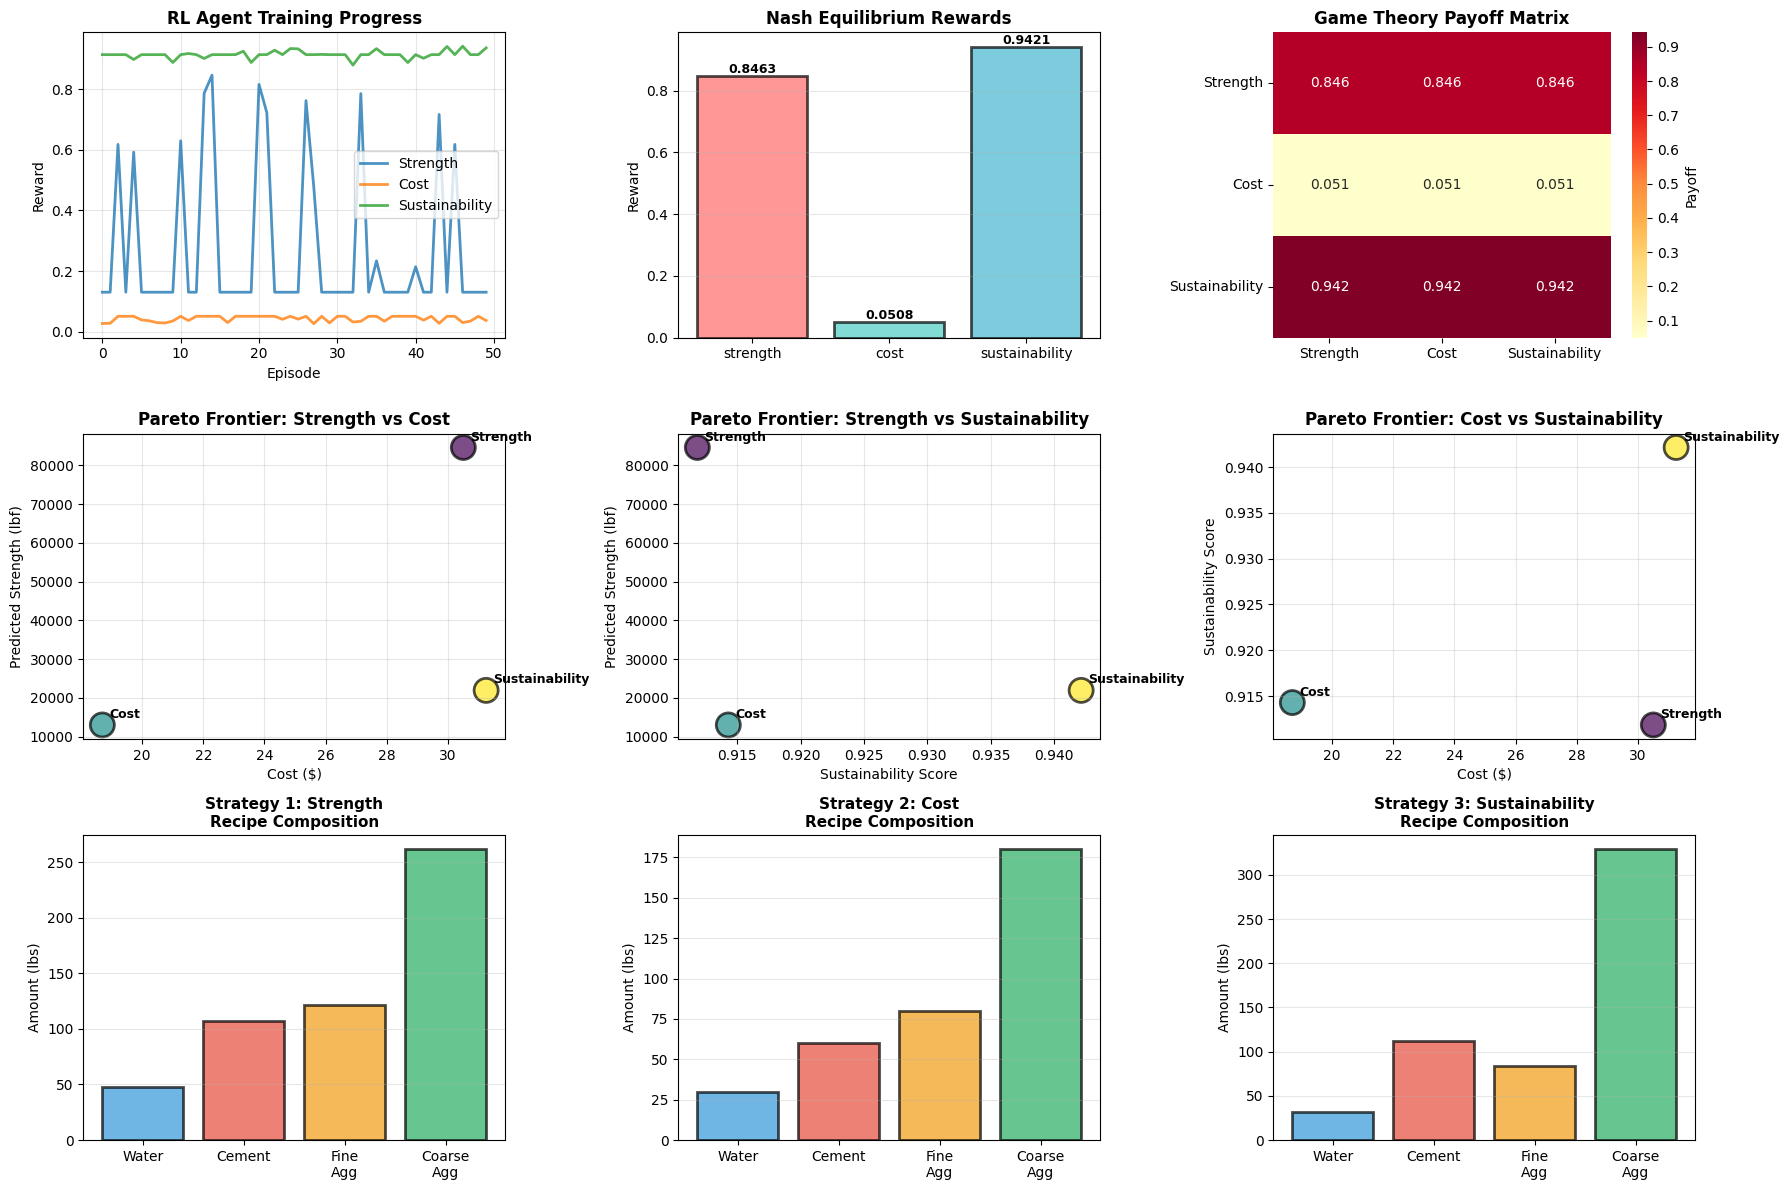


 VISUALIZATION COMPLETE!


In [19]:
print("\n Creating visualizations...")

fig = plt.figure(figsize=(18, 12))

# 1. RL Training Progress
ax1 = plt.subplot(3, 3, 1)
for obj in objectives:
    ax1.plot(reward_history[obj], label=obj.capitalize(), linewidth=2, alpha=0.8)
ax1.set_xlabel('Episode', fontsize=10)
ax1.set_ylabel('Reward', fontsize=10)
ax1.set_title('RL Agent Training Progress', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Best Rewards Comparison
ax2 = plt.subplot(3, 3, 2)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax2.bar(objectives, [best_rewards[obj] for obj in objectives], color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Reward', fontsize=10)
ax2.set_title('Nash Equilibrium Rewards', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Payoff Matrix Heatmap
ax3 = plt.subplot(3, 3, 3)
payoff_data = np.array([[payoff_matrix[obj1][obj2] for obj2 in objectives] for obj1 in objectives])
sns.heatmap(payoff_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax3, cbar_kws={'label': 'Payoff'})
ax3.set_xticklabels([obj.capitalize() for obj in objectives])
ax3.set_yticklabels([obj.capitalize() for obj in objectives], rotation=0)
ax3.set_title('Game Theory Payoff Matrix', fontsize=12, fontweight='bold')

# 4. Strength vs Cost
ax4 = plt.subplot(3, 3, 4)
strengths = [agent.predict_strength(best_recipes[obj]) for obj in objectives]
costs = [calculate_cost(best_recipes[obj]) for obj in objectives]
scatter = ax4.scatter(costs, strengths, s=300, c=range(len(objectives)), cmap='viridis', alpha=0.7, edgecolors='black', linewidth=2)
for i, obj in enumerate(objectives):
    ax4.annotate(obj.capitalize(), (costs[i], strengths[i]), xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
ax4.set_xlabel('Cost ($)', fontsize=10)
ax4.set_ylabel('Predicted Strength (lbf)', fontsize=10)
ax4.set_title('Pareto Frontier: Strength vs Cost', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)

# 5. Strength vs Sustainability
ax5 = plt.subplot(3, 3, 5)
susts = [calculate_sustainability(best_recipes[obj]) for obj in objectives]
scatter = ax5.scatter(susts, strengths, s=300, c=range(len(objectives)), cmap='viridis', alpha=0.7, edgecolors='black', linewidth=2)
for i, obj in enumerate(objectives):
    ax5.annotate(obj.capitalize(), (susts[i], strengths[i]), xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
ax5.set_xlabel('Sustainability Score', fontsize=10)
ax5.set_ylabel('Predicted Strength (lbf)', fontsize=10)
ax5.set_title('Pareto Frontier: Strength vs Sustainability', fontsize=12, fontweight='bold')
ax5.grid(alpha=0.3)

# 6. Cost vs Sustainability
ax6 = plt.subplot(3, 3, 6)
scatter = ax6.scatter(costs, susts, s=300, c=range(len(objectives)), cmap='viridis', alpha=0.7, edgecolors='black', linewidth=2)
for i, obj in enumerate(objectives):
    ax6.annotate(obj.capitalize(), (costs[i], susts[i]), xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
ax6.set_xlabel('Cost ($)', fontsize=10)
ax6.set_ylabel('Sustainability Score', fontsize=10)
ax6.set_title('Pareto Frontier: Cost vs Sustainability', fontsize=12, fontweight='bold')
ax6.grid(alpha=0.3)

# 7. Material Composition - Strategy 1 (Strength)
ax7 = plt.subplot(3, 3, 7)
materials1 = ['Water', 'Cement', 'Fine\nAgg', 'Coarse\nAgg']
amounts1 = s1[:4]
ax7.bar(materials1, amounts1, color=['#3498db', '#e74c3c', '#f39c12', '#27ae60'], alpha=0.7, edgecolor='black', linewidth=2)
ax7.set_ylabel('Amount (lbs)', fontsize=10)
ax7.set_title('Strategy 1: Strength\nRecipe Composition', fontsize=11, fontweight='bold')
ax7.grid(alpha=0.3, axis='y')

# 8. Material Composition - Strategy 2 (Cost)
ax8 = plt.subplot(3, 3, 8)
amounts2 = s2[:4]
ax8.bar(materials1, amounts2, color=['#3498db', '#e74c3c', '#f39c12', '#27ae60'], alpha=0.7, edgecolor='black', linewidth=2)
ax8.set_ylabel('Amount (lbs)', fontsize=10)
ax8.set_title('Strategy 2: Cost\nRecipe Composition', fontsize=11, fontweight='bold')
ax8.grid(alpha=0.3, axis='y')

# 9. Material Composition - Strategy 3 (Sustainability)
ax9 = plt.subplot(3, 3, 9)
amounts3 = s3[:4]
ax9.bar(materials1, amounts3, color=['#3498db', '#e74c3c', '#f39c12', '#27ae60'], alpha=0.7, edgecolor='black', linewidth=2)
ax9.set_ylabel('Amount (lbs)', fontsize=10)
ax9.set_title('Strategy 3: Sustainability\nRecipe Composition', fontsize=11, fontweight='bold')
ax9.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sweetcrete_rl_game_theory_analysis.png', dpi=300, bbox_inches='tight')
print(" Visualization saved to: sweetcrete_rl_game_theory_analysis.png")
plt.show()

print("\n" + "="*80)
print(" VISUALIZATION COMPLETE!")
print("="*80)


📊 Creating visualizations...
 Visualization saved to: sweetcrete_rl_game_theory_analysis.png


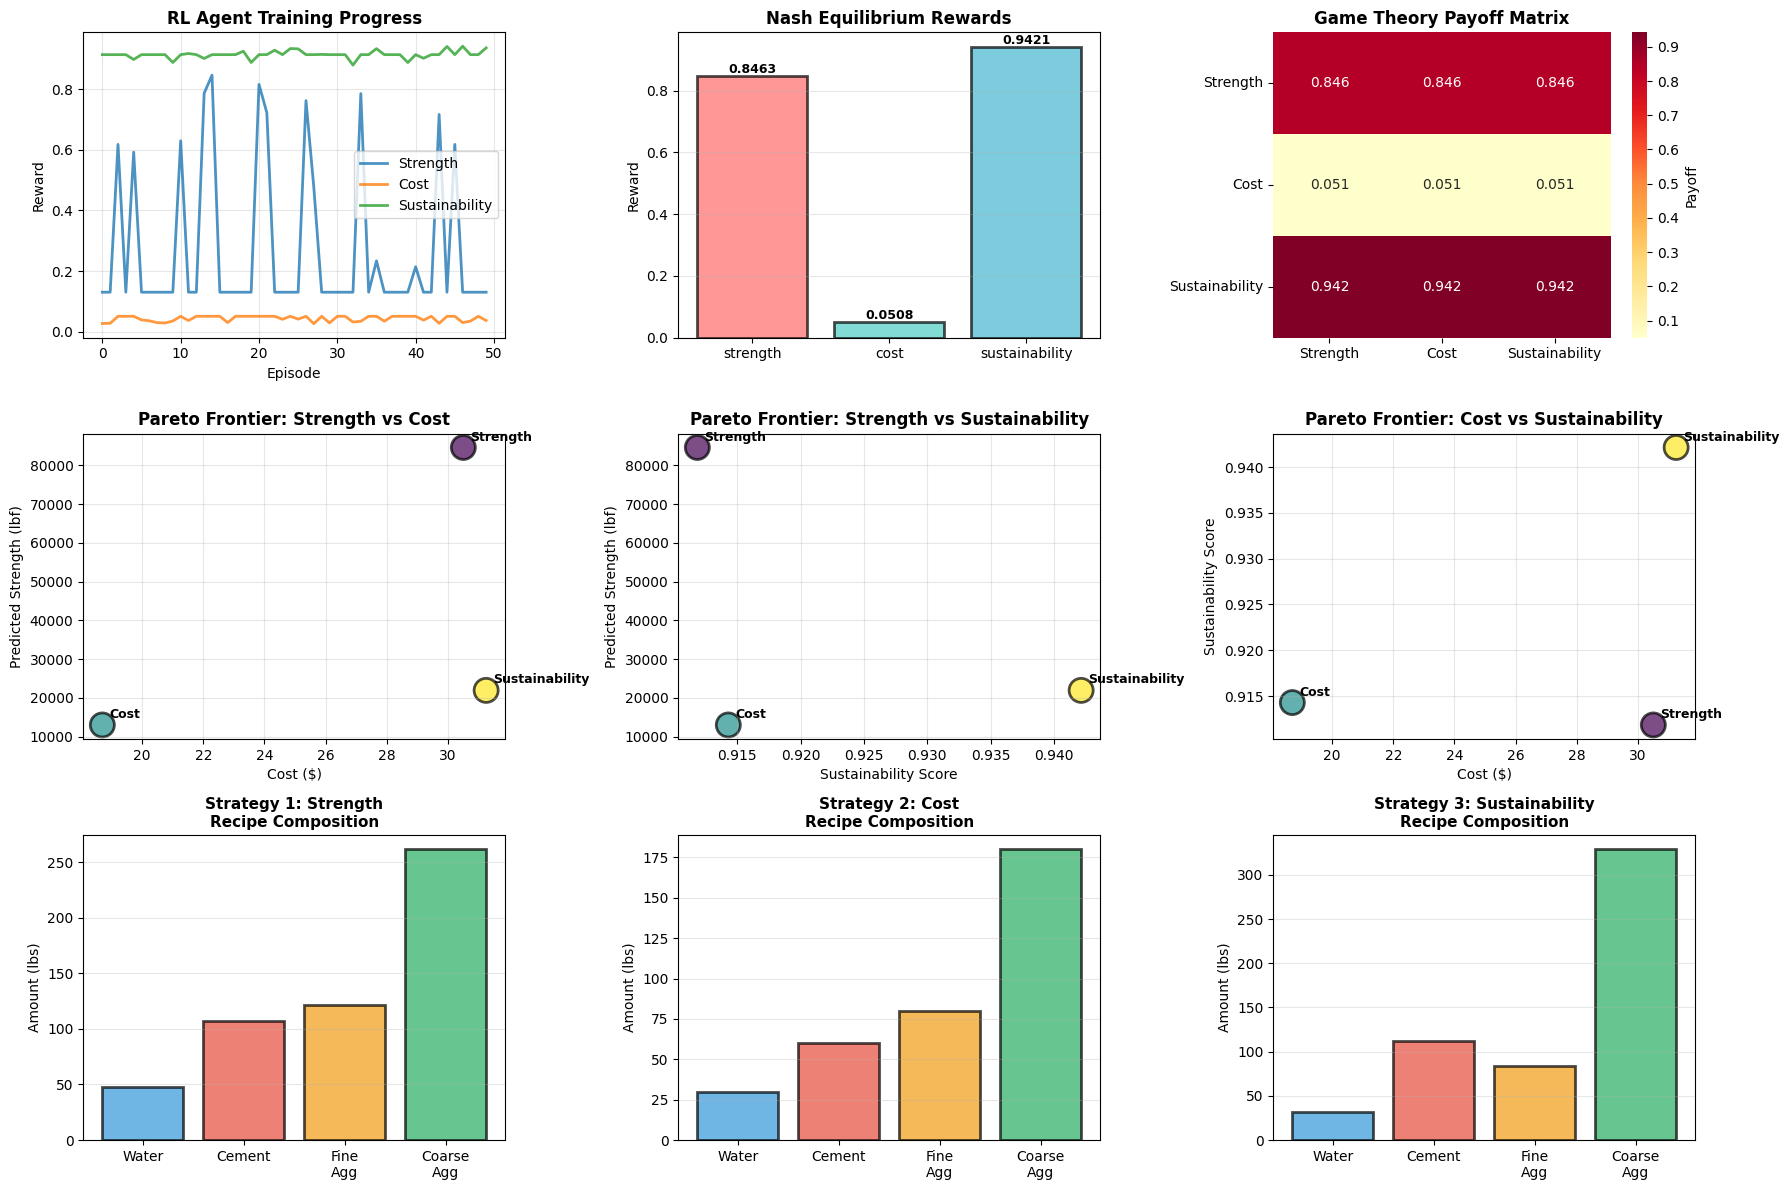


 VISUALIZATION COMPLETE!


In [14]:
print("\n Creating visualizations...")

fig = plt.figure(figsize=(18, 12))

# 1. RL Training Progress
ax1 = plt.subplot(3, 3, 1)
for obj in objectives:
    ax1.plot(reward_history[obj], label=obj.capitalize(), linewidth=2, alpha=0.8)
ax1.set_xlabel('Episode', fontsize=10)
ax1.set_ylabel('Reward', fontsize=10)
ax1.set_title('RL Agent Training Progress', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Best Rewards Comparison
ax2 = plt.subplot(3, 3, 2)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax2.bar(objectives, [best_rewards[obj] for obj in objectives], color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Reward', fontsize=10)
ax2.set_title('Nash Equilibrium Rewards', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Payoff Matrix Heatmap
ax3 = plt.subplot(3, 3, 3)
payoff_data = np.array([[payoff_matrix[obj1][obj2] for obj2 in objectives] for obj1 in objectives])
sns.heatmap(payoff_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax3, cbar_kws={'label': 'Payoff'})
ax3.set_xticklabels([obj.capitalize() for obj in objectives])
ax3.set_yticklabels([obj.capitalize() for obj in objectives], rotation=0)
ax3.set_title('Game Theory Payoff Matrix', fontsize=12, fontweight='bold')

# 4. Strength vs Cost
ax4 = plt.subplot(3, 3, 4)
strengths = [agent.predict_strength(best_recipes[obj]) for obj in objectives]
costs = [calculate_cost(best_recipes[obj]) for obj in objectives]
scatter = ax4.scatter(costs, strengths, s=300, c=range(len(objectives)), cmap='viridis', alpha=0.7, edgecolors='black', linewidth=2)
for i, obj in enumerate(objectives):
    ax4.annotate(obj.capitalize(), (costs[i], strengths[i]), xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
ax4.set_xlabel('Cost ($)', fontsize=10)
ax4.set_ylabel('Predicted Strength (lbf)', fontsize=10)
ax4.set_title('Pareto Frontier: Strength vs Cost', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)

# 5. Strength vs Sustainability
ax5 = plt.subplot(3, 3, 5)
susts = [calculate_sustainability(best_recipes[obj]) for obj in objectives]
scatter = ax5.scatter(susts, strengths, s=300, c=range(len(objectives)), cmap='viridis', alpha=0.7, edgecolors='black', linewidth=2)
for i, obj in enumerate(objectives):
    ax5.annotate(obj.capitalize(), (susts[i], strengths[i]), xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
ax5.set_xlabel('Sustainability Score', fontsize=10)
ax5.set_ylabel('Predicted Strength (lbf)', fontsize=10)
ax5.set_title('Pareto Frontier: Strength vs Sustainability', fontsize=12, fontweight='bold')
ax5.grid(alpha=0.3)

# 6. Cost vs Sustainability
ax6 = plt.subplot(3, 3, 6)
scatter = ax6.scatter(costs, susts, s=300, c=range(len(objectives)), cmap='viridis', alpha=0.7, edgecolors='black', linewidth=2)
for i, obj in enumerate(objectives):
    ax6.annotate(obj.capitalize(), (costs[i], susts[i]), xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
ax6.set_xlabel('Cost ($)', fontsize=10)
ax6.set_ylabel('Sustainability Score', fontsize=10)
ax6.set_title('Pareto Frontier: Cost vs Sustainability', fontsize=12, fontweight='bold')
ax6.grid(alpha=0.3)

# 7. Material Composition - Strategy 1 (Strength)
ax7 = plt.subplot(3, 3, 7)
materials1 = ['Water', 'Cement', 'Fine\nAgg', 'Coarse\nAgg']
amounts1 = s1[:4]
ax7.bar(materials1, amounts1, color=['#3498db', '#e74c3c', '#f39c12', '#27ae60'], alpha=0.7, edgecolor='black', linewidth=2)
ax7.set_ylabel('Amount (lbs)', fontsize=10)
ax7.set_title('Strategy 1: Strength\nRecipe Composition', fontsize=11, fontweight='bold')
ax7.grid(alpha=0.3, axis='y')

# 8. Material Composition - Strategy 2 (Cost)
ax8 = plt.subplot(3, 3, 8)
amounts2 = s2[:4]
ax8.bar(materials1, amounts2, color=['#3498db', '#e74c3c', '#f39c12', '#27ae60'], alpha=0.7, edgecolor='black', linewidth=2)
ax8.set_ylabel('Amount (lbs)', fontsize=10)
ax8.set_title('Strategy 2: Cost\nRecipe Composition', fontsize=11, fontweight='bold')
ax8.grid(alpha=0.3, axis='y')

# 9. Material Composition - Strategy 3 (Sustainability)
ax9 = plt.subplot(3, 3, 9)
amounts3 = s3[:4]
ax9.bar(materials1, amounts3, color=['#3498db', '#e74c3c', '#f39c12', '#27ae60'], alpha=0.7, edgecolor='black', linewidth=2)
ax9.set_ylabel('Amount (lbs)', fontsize=10)
ax9.set_title('Strategy 3: Sustainability\nRecipe Composition', fontsize=11, fontweight='bold')
ax9.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sweetcrete_rl_game_theory_analysis.png', dpi=300, bbox_inches='tight')
print(" Visualization saved to: sweetcrete_rl_game_theory_analysis.png")
plt.show()

print("\n" + "="*80)
print(" VISUALIZATION COMPLETE!")
print("="*80)